# Milestone 6: Model Evaluation

This notebook evaluates the machine learning model using classification metrics to measure predictive performance on unseen test data.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

X_train = pd.read_csv('/content/X_train.csv')
X_test = pd.read_csv('/content/X_test.csv')
y_train = pd.read_csv('/content/y_train.csv').squeeze()
y_test = pd.read_csv('/content/y_test.csv').squeeze()

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

## Model Retraining

The optimized Random Forest model is retrained using the full training dataset before final evaluation on unseen test data.


In [5]:
# 1. Retrain on full training set
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=4,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

## Final Evaluation Metrics

The trained model is evaluated using several classification metrics including Accuracy, F1 Score, Precision, Recall, and ROC-AUC.

In [6]:
# 2. Final Evaluation on Test Set
y_final_pred = final_model.predict(X_test)
y_final_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC'],
    'Final Test Score': [
        accuracy_score(y_test, y_final_pred),
        f1_score(y_test, y_final_pred),
        precision_score(y_test, y_final_pred),
        recall_score(y_test, y_final_pred),
        roc_auc_score(y_test, y_final_proba)
    ]
}

final_metrics_df = pd.DataFrame(final_metrics)
display(final_metrics_df.round(4))

,Metric,Final Test Score
0,Accuracy,0.8478
1,F1 Score,0.8679
2,Precision,0.8364
3,Recall,0.9020
4,ROC-AUC,0.9371


## Confusion Matrix and ROC Curve

The confusion matrix visualizes prediction performance, while the ROC curve illustrates the model’s ability to distinguish between classes across different thresholds.

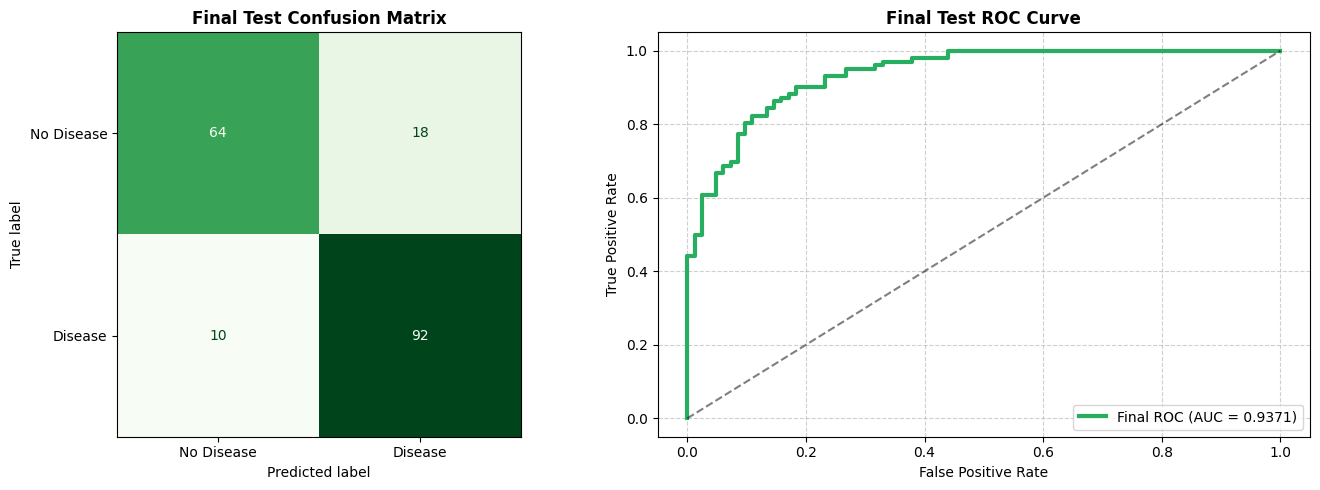

In [7]:
# 3. Visual Evidence: Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Final Test Confusion Matrix', fontweight='bold')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_final_proba)
auc_val = roc_auc_score(y_test, y_final_proba)
axes[1].plot(fpr, tpr, color='#27AE60', lw=3, label=f'Final ROC (AUC = {auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Final Test ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('m5_final_evaluation.png', dpi=150)
plt.show()